# Model Evaluation & Inference
This notebook demonstrates how to load the trained Face Similarity model, calculate evaluation metrics, and perform single-pair inference.

In [1]:
import sys
import torch
import torchvision.transforms as transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# Add the project root to path
sys.path.append('..')

from face_similarity import EmbeddingNet, get_transforms, compute_similarity, evaluate
from argparse import Namespace

## 1. Define device and load model

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

checkpoint_path = "./checkpoints/best.pt"
ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)

embedding_dim = ckpt.get('embedding_dim', 256)
img_size = ckpt.get('img_size', 112)

model = EmbeddingNet(embedding_dim=embedding_dim).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print("Model loaded successfully.")

Using device: mps
Model loaded successfully.


## 2. Single Pair Inference
Let's test the model on two images and compute their cosine distance.

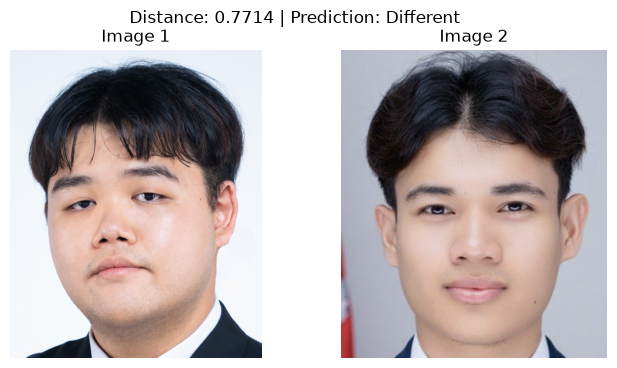

In [5]:
# Choose two images to compare from the test set
# Modify paths based on actual available images
# img1_path = "./dataset/raw/subjects_0-1999_72_imgs/1212/0.png"
# img2_path = "./dataset/raw/subjects_0-1999_72_imgs/1212/1.png"

# img1_path = "./dataset/raw/casia_webface_extracted/0/0.jpg"
# img2_path = "./dataset/raw/casia_webface_extracted/1/0.jpg"

img1_path = "Khoun_Sovansunchhay.jpg"
img2_path = "oudom.png"

try:
    dist, is_same = compute_similarity(model, img1_path, img2_path, device, img_size=img_size, threshold=0.415)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
    ax1.imshow(Image.open(img1_path))
    ax1.axis('off')
    ax1.set_title('Image 1')
    
    ax2.imshow(Image.open(img2_path))
    ax2.axis('off')
    ax2.set_title('Image 2')
    
    plt.suptitle(f"Distance: {dist:.4f} | Prediction: {'Same' if is_same else 'Different'}")
    plt.show()
except FileNotFoundError:
    print(f"Please update the paths for img1_path and img2_path with actual images.")

## 3. Run Full Test Set Evaluation
Calculates FAR/FRR metrics across a sample of pairs.

In [8]:
args = Namespace(
    checkpoint="./checkpoints/best.pt",
    eval_split="test",
    manifest_csv="./dataset/splits/manifest.csv",
    project_root=".",
    embedding_dim=256,
    img_size=112,
    max_pairs=500_000
)

results = evaluate(args)

[Device] Using mps
[Model] Loaded from ./checkpoints/best.pt (epoch 29)
[Dataset] Loaded 4320 images across 60 identities (split='test') from ./dataset/splits/manifest.csv
[Eval] Extracting embeddings for 4320 images...
[Eval] Computing FAR/FRR...
  [Eval] Subsampled 500000 pairs from 9329040
  [Eval] Pairs — genuine: 8276, impostor: 491724

EVALUATION RESULTS (FAR / FRR)
  Genuine pairs:  8276
  Impostor pairs: 491724
  EER:            0.0922 @ threshold=0.4150

  Threshold    FAR        FRR
  ---------    -------    -------
  0.20         0.2655     0.0489
  0.30         0.1700     0.0660
  0.40         0.1007     0.0870
  0.50         0.0558     0.1242
  0.60         0.0294     0.1711
  0.70         0.0143     0.2386

